<a href="https://colab.research.google.com/github/samuelmwai-boop/ds-perfection/blob/main/day2_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

#load a real dataset
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

#First look
print(df.shape)
print(df.head())
print(df.dtypes)

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [2]:
#How many missing values in each column?
print(df.isnull().sum)

<bound method DataFrame.sum of      PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False 

In [3]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Fix Age — fill with average age
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fix Embarked — fill with most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fix Cabin — drop the column entirely
df = df.drop(columns=["Cabin"])

# Verify — check missing values again
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Filled missing ages with the average — imputation
Filled missing ports with the most common value — mode imputation
Dropped a column that was 77% empty — feature removal

In [5]:
# What was the survival rate by gender?
survival_by_gender = df.groupby("Sex")["Survived"].mean() * 100
print(survival_by_gender)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


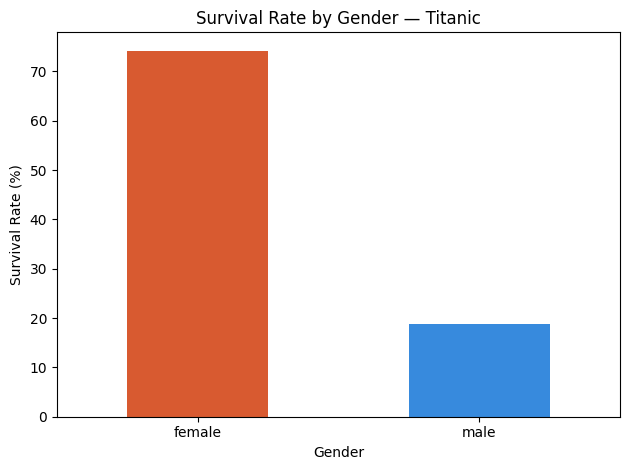

In [6]:
import matplotlib.pyplot as plt

survival_by_gender.plot(kind="bar", color=["#D85A30", "#378ADD"])
plt.title("Survival Rate by Gender — Titanic")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

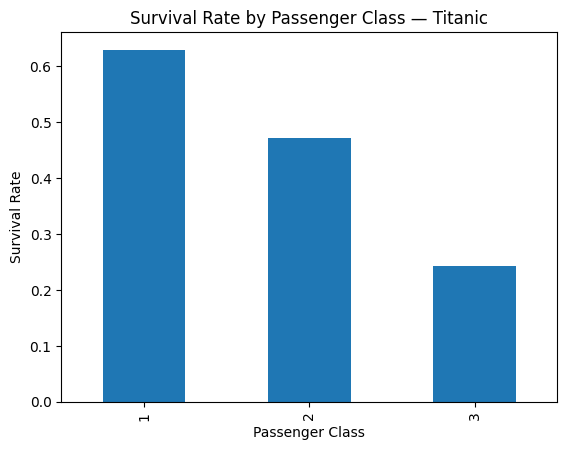

In [7]:
import matplotlib.pyplot as plt

# Group by Pclass and get survival rate
survival_by_class = df.groupby("Pclass")["Survived"].mean()

# Plot
survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class — Titanic")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()